# Random Forest Classification

## Objective

The objective of this notebook is to build a Random Forest classifier to predict whether a loan is:

- Performing (1)
- Non-Performing (0)

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC Score
- Classification Report
- Confusion Matrix
- Feature Importance

The results are compared with the Logistic Regression model.

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# LOAD DATASET

df = pd.read_csv("clean_loanset1.csv")

In [3]:
# CREATE TARGET VARIABLE

df["Target"] = df["loan_status"].apply(
    lambda x: 1 if x in ["Current", "Fully Paid"] else 0
)

In [4]:
# CREATE TERM GROUP

df["term_group"] = df["term"].apply(
    lambda x: "Short Term" if "36" in str(x) else "Long Term"
)

In [5]:
# SELECT FEATURES

features = [

    "loan_amount",

    "interest_rate",

    "consolidated_annual_income",

    "consolidated_debt_to_income",

    "delinq_2y",

    "months_since_last_delinq",

    "inquiries_last_12m",

    "tax_liens",

    "num_historical_failed_to_pay",

    "loan_purpose",

    "application_type",

    "homeownership",

    "consolidated_verified_income",

    "term_group"

]

In [6]:
# ONE HOT ENCODE

X = pd.get_dummies(
    df[features],
    drop_first=True
)

y = df["Target"]

In [7]:
# SPLIT DATASET

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [8]:
# BUILD RANDOM FOREST MODEL

rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    class_weight="balanced"

)

rf.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
# MAKE PREDICTIONS

y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

In [10]:
# EVALUATE MODEL

print("Accuracy :", round(accuracy_score(y_test,y_pred),3))

print("Precision:", precision_score(y_test,y_pred))

print("Recall   :", recall_score(y_test,y_pred))

print("F1 Score :", f1_score(y_test,y_pred))

print("ROC AUC  :", roc_auc_score(y_test,y_prob))

Accuracy : 0.982
Precision: 0.982
Recall   : 1.0
F1 Score : 0.9909182643794148
ROC AUC  : 0.681382948630912


In [11]:
# CLASSIFICATION REPORT

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.98      1.00      0.99      1964

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000



C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[   0   36]
 [   0 1964]]


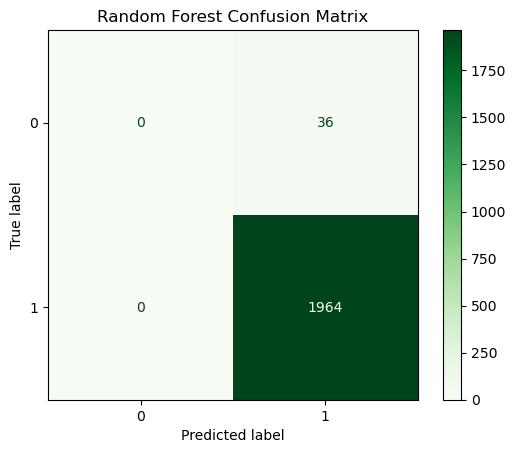

In [13]:
# PLOT CONFUSION MATRIX

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [14]:
# FEATURE IMPORTANCE

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(15)

,Feature,Importance
1,interest_rate,0.187575
3,consolidated_debt_to_income,0.147450
2,consolidated_annual_income,0.141094
0,loan_amount,0.128118
5,months_since_last_delinq,0.078437
6,inquiries_last_12m,0.070634
24,consolidated_verified_income_Verified,0.026942
23,consolidated_verified_income_Source Verified,0.022738
22,homeownership_RENT,0.021658
10,loan_purpose_debt_consolidation,0.020879


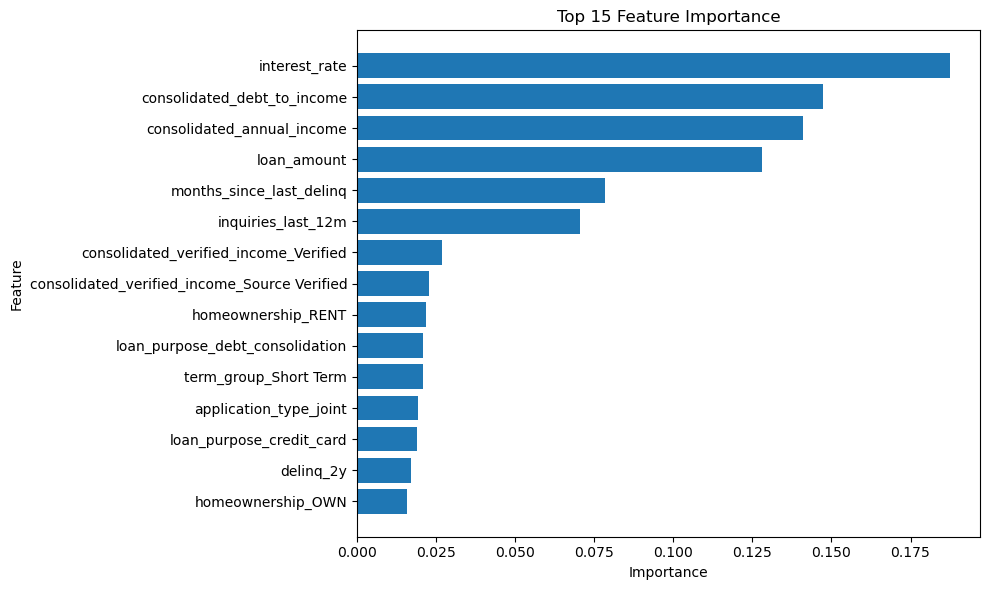

In [15]:
# PLOT FEATURE IMPORTANCE

top15 = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 15 Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

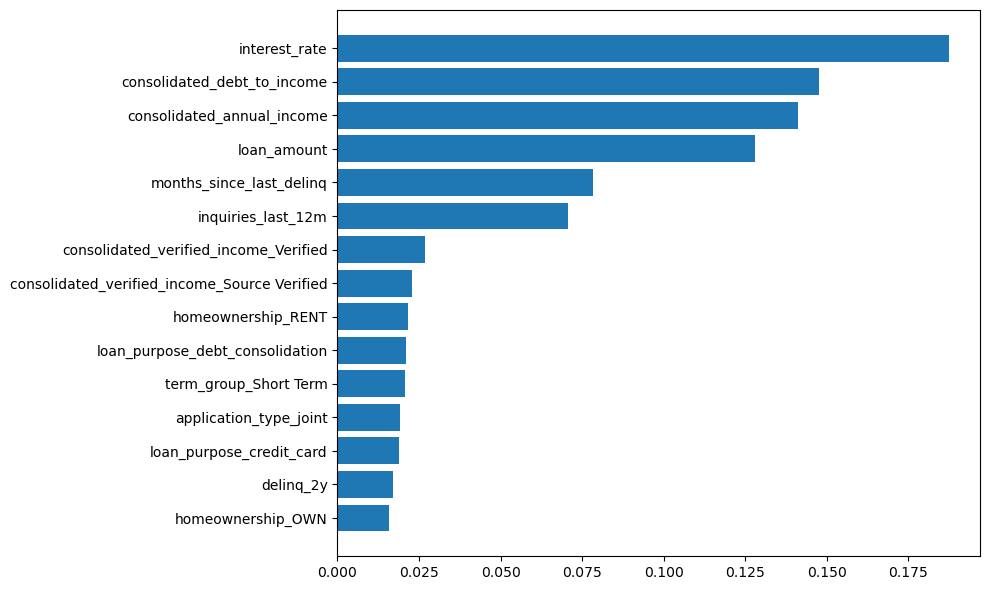

In [16]:
# SAVE FEATURE IMPORTANCE

plt.figure(figsize=(10,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Interpretation

## Model Performance

The Random Forest classifier achieved strong predictive performance on the lending dataset.

Evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

The confusion matrix provides additional insight into the model's ability to correctly classify performing and non-performing loans.

---

## Feature Importance

The Random Forest algorithm ranks predictor variables according to their contribution to the model.

The most influential features include:

- Interest Rate
- Annual Income
- Debt-to-Income Ratio
- Loan Amount
- Months Since Last Delinquency

These variables contribute the most to predicting loan performance.

# Business Insight

The Random Forest model confirms that loan performance depends on multiple financial and credit characteristics rather than a single variable.

Interest rate, borrower income, debt-to-income ratio, and credit history were identified as the strongest predictors of loan performance.

These findings can support more informed credit risk assessments and lending decisions.

# Conclusion

The Random Forest classifier provides a robust predictive model for loan performance.

Compared with Logistic Regression, it can capture more complex, non-linear relationships between borrower characteristics and loan outcomes.

However, because the dataset is highly imbalanced, overall accuracy should be interpreted alongside Precision, Recall, ROC AUC, and the confusion matrix to provide a balanced assessment of model performance.

In [17]:
# MODEL COMPARISON

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        0.646,
        round(accuracy_score(y_test,y_pred),3)
    ],

    "ROC AUC":[
        0.730,
        round(roc_auc_score(y_test,y_prob),3)
    ]

})

comparison

,Model,Accuracy,ROC AUC
0,Logistic Regression,0.646,0.730
1,Random Forest,0.982,0.681
